In [1]:
import pandas as pd
import numpy as np
import json
import os
from jiwer import wer, cer
from datasets import load_dataset
import re
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import jiwer

c:\Users\ATHO0358\Documents\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Experiment 1: Statistical Analysis Tests

## Wilcoxon Rank Sum Test
This test is done as it conducts a comparison between two completely independent groups, which in this case are the clean CoRal dataset and the messy Wrist-Angel dataset.

In [18]:
import numpy as np
import torch
from sentence_transformers import SentenceTransformer, util

def compute_sentence_semantic_distance(
    references: list[str], 
    hypotheses: list[str], 
    model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
) -> list[float]:
    """
    Calculates the Sentence Semantic Distance (1 - Cosine Similarity) 
    between reference and ASR hypothesis transcripts.
    """
    model = SentenceTransformer(model_name)
    
    ref_embeddings = model.encode(references, convert_to_tensor=True, show_progress_bar=False)
    hyp_embeddings = model.encode(hypotheses, convert_to_tensor=True, show_progress_bar=False)

    cosine_sims = util.cos_sim(ref_embeddings, hyp_embeddings).diagonal()
    
    semantic_distances = 1.0 - cosine_sims.cpu().numpy()
    semantic_distances = np.clip(semantic_distances, 0.0, 2.0)
    
    return semantic_distances.tolist()


In [ ]:
def process_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """
    Expects a DataFrame with 'audio_id', 'reference', and 'hypothesis' columns.
    Returns the DataFrame with added 'wer' and 'cer' columns.
    """
    df = df.copy()
    
    # Calculate WER and CER per row (utterance)
    df['wer'] = df.apply(lambda row: jiwer.wer(row['ref'], row['hyp']), axis=1)
    df['cer'] = df.apply(lambda row: jiwer.cer(row['ref'], row['hyp']), axis=1)
    
    return df

In [28]:
import pandas as pd
import jiwer
from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import cosine

# 1. Load the embedding model globally
# 'all-MiniLM-L6-v2' is the industry standard for fast, accurate semantic similarity
print("Loading Semantic Model...")
semantic_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

def process_dataset_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes utterance-level WER, CER, and SemDist for a given DataFrame.
    Expects 'reference' and 'hypothesis' columns.
    """
    df = df.copy()
    print("Computing WER and CER...")
    df['wer'] = df.apply(lambda row: jiwer.wer(row['ref'], row['hyp']), axis=1)
    df['cer'] = df.apply(lambda row: jiwer.cer(row['ref'], row['hyp']), axis=1)
    
    print("Computing Semantic Distance...")
    
    references = df['ref'].tolist()
    hypotheses = df['hyp'].tolist()
    
    ref_embeddings = semantic_model.encode(references, batch_size=32, show_progress_bar=True)
    hyp_embeddings = semantic_model.encode(hypotheses, batch_size=32, show_progress_bar=True)
    
    sem_distances = []
    for ref_emb, hyp_emb in zip(ref_embeddings, hyp_embeddings):
        dist = cosine(ref_emb, hyp_emb)
        sem_distances.append(dist)
        
    df['semdist'] = sem_distances
    
    return df


Loading Semantic Model...


In [ ]:
def load_nested_jsonl_to_df(file_path: str) -> pd.DataFrame:
    flattened_records = []
    
    with open(file_path, 'r', encoding='utf-8') as file:
        for line_number, line in enumerate(file, start=1):
            line = line.strip()
            if not line:
                continue  # Skip empty lines
                
            try:
                # Parse the JSON string into a Python object (expected to be a list)
                line_data = json.loads(line)
                
                # Check if the parsed object is actually a list
                if isinstance(line_data, list):
                    # .extend() un-nests the list and adds the individual dicts
                    flattened_records.extend(line_data)
                else:
                    print(f"Warning: Line {line_number} is not a list. Skipping.")
                    
            except json.JSONDecodeError as e:
                print(f"Error parsing JSON on line {line_number}: {e}")
                
    # Convert the flat list of dictionaries into a DataFrame
    return pd.DataFrame(flattened_records)

In [29]:
wa_df = load_nested_jsonl_to_df('L:/Auditdata/Wrist Angel - Video/Amalie Sommer/repo/thesis_multi_speaker_asr/results/wa_wav2vec2_baseline.jsonl')
processed_wa_df = process_dataset_metrics(wa_df)

coral_df = load_nested_jsonl_to_df('L:/Auditdata/Wrist Angel - Video/Amalie Sommer/repo/thesis_multi_speaker_asr/wav2vec2_baseline.jsonl')
processed_coral_df = process_dataset_metrics(coral_df)

Computing WER and CER...
Computing Semantic Distance...


Batches: 100%|██████████| 98/98 [00:29<00:00,  3.36it/s]


Computing WER and CER...
Computing Semantic Distance...


Batches: 100%|██████████| 792/792 [02:52<00:00,  4.58it/s]


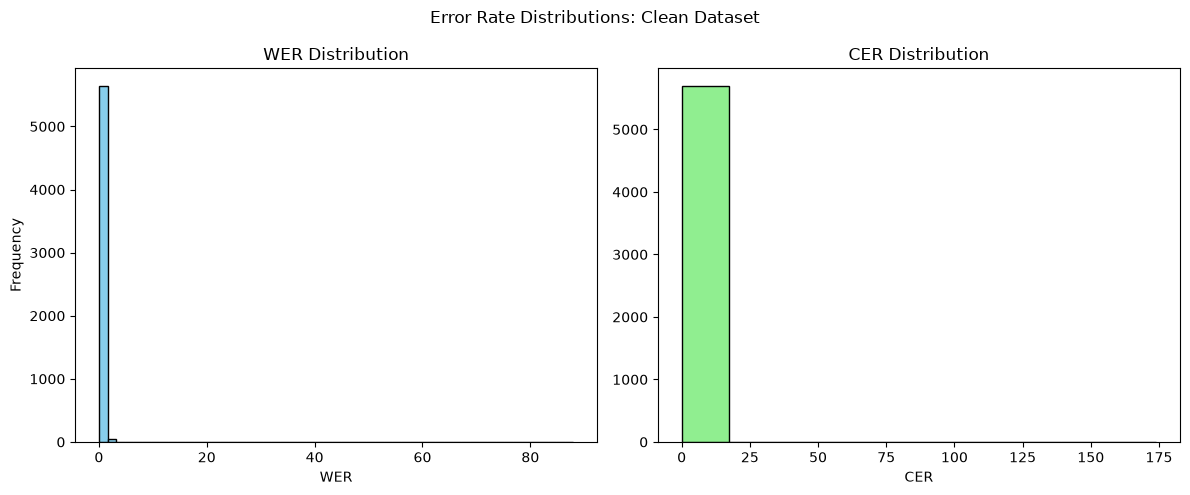

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_simple_histograms(df: pd.DataFrame, dataset_name: str):
    """
    Plots basic histograms for WER and CER to visually check the distribution.
    """
    # Create a simple 1x2 grid for WER and CER
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Error Rate Distributions: {dataset_name}')

    # Plot WER
    axes[0].hist(df['wer'].dropna(), bins=55, color='skyblue', edgecolor='black')
    axes[0].set_title('WER Distribution')
    axes[0].set_xlabel('WER')
    axes[0].set_ylabel('Frequency')

    # Plot CER
    axes[1].hist(df['cer'].dropna(), bins=10, color='lightgreen', edgecolor='black')
    axes[1].set_title('CER Distribution')
    axes[1].set_xlabel('CER')
    
    plt.tight_layout()
    plt.show()

plot_simple_histograms(processed_coral_df, 'Clean Dataset')

In [ ]:
import scipy.stats as stats
import pandas as pd

def compare_datasets(df_clean: pd.DataFrame, df_messy: pd.DataFrame, metric: str):
    """
    Runs a Wilcoxon Rank-Sum (Mann-Whitney U) test to compare a metric 
    across two independent datasets.
    """
    clean_data = df_clean[metric].dropna()
    messy_data = df_messy[metric].dropna()
    
    stat, p_value = stats.mannwhitneyu(clean_data, messy_data, alternative='less')
    
    print(f"--- Wilcoxon Rank-Sum Test for {metric.upper()} ---")
    print(f"Clean median: {clean_data.median():.4f} | Messy median: {messy_data.median():.4f}")
    print(f"Statistic (U): {stat}")
    print(f"P-value:       {p_value:.4e}")
    
    # Interpretation
    if p_value < 0.05:
        print("Result: Statistically significant. The messy dataset has higher error rates.")
    else:
        print("Result: Not statistically significant. We cannot conclude the messy data is worse.")
    print("-" * 50)


In [30]:
compare_datasets(df_clean=processed_coral_df, df_messy=processed_wa_df, metric='wer')
compare_datasets(df_clean=processed_coral_df, df_messy=processed_wa_df, metric='cer')
compare_datasets(df_clean=processed_coral_df, df_messy=processed_wa_df, metric='semdist')

--- Wilcoxon Rank-Sum Test for WER ---
Clean median: 0.3750 | Messy median: 0.8571
Statistic (U): 11796943.5
P-value:       0.0000e+00
Result: Statistically significant. The messy dataset has higher error rates.
--------------------------------------------------
--- Wilcoxon Rank-Sum Test for CER ---
Clean median: 0.1569 | Messy median: 0.5385
Statistic (U): 10107004.5
P-value:       0.0000e+00
Result: Statistically significant. The messy dataset has higher error rates.
--------------------------------------------------
--- Wilcoxon Rank-Sum Test for SEMDIST ---
Clean median: 0.0849 | Messy median: 0.3586
Statistic (U): 14872512.0
P-value:       0.0000e+00
Result: Statistically significant. The messy dataset has higher error rates.
--------------------------------------------------


## Friedman's Test
This is the statistic method chosen for the comparison of the three types of speaker labels within the Wrist-Angel dataset, in order to gain insights into whether the model performs poorly across all speakers or if one or two stand out as being significantly more difficult for the model to understand.

In [46]:
speaker_labels_df = pd.read_csv(
    'L:/Auditdata/Wrist Angel - Video/Amalie Sommer/repo/thesis_multi_speaker_asr/results/ground_truth/transcripts.rttm',
    header=None,
    sep='\s+',
    usecols=[1, 4, 7]
    )
labels_df = speaker_labels_df.rename(columns={1: 'audio_id', 4: 'seg_end', 7: 'speaker'})

In [62]:
merged_speaker_wa_df = pd.merge(processed_wa_df, labels_df, on=['audio_id', 'seg_end'], how='inner').reset_index(drop=True)

In [63]:
merged_speaker_wa_df.drop_duplicates(inplace=True)

In [64]:
merged_speaker_wa_df.head(10)

,audio_id,segment_id,ref,seg_start,seg_end,wer,cer,hyp,semdist,speaker
0,id18_baseline_suds,id18_baseline_suds_segID_0,Og når man prøver at arbejde mod OCDen så i vi...,0,39.0,0.338843,0.149180,arbejde mod usibien så e i virkeligheden så sk...,0.117203,I
1,id18_baseline_suds,id18_baseline_suds_segID_2,"Okay. Så du kan mærke i kroppen, at det er rig...",0,6.0,0.500000,0.209677,okay så du kan mærke i kroppen der er rigtig u...,0.126098,I
4,id18_baseline_suds,id18_baseline_suds_segID_2,"Okay. Så du kan mærke i kroppen, at det er rig...",0,6.0,0.500000,0.209677,okay så du kan mærke i kroppen der er rigtig u...,0.126098,B
5,id18_baseline_suds,id18_baseline_suds_segID_3,Ja.,0,3.0,6.000000,8.666667,o man har det så ubehælligt,0.360425,B
6,id18_baseline_suds,id18_baseline_suds_segID_3,Ja.,0,3.0,6.000000,8.666667,o man har det så ubehælligt,0.360425,I
11,id18_baseline_suds,id18_baseline_suds_segID_4,"Og når man har det så ubehageligt, så plejer v...",0,38.0,0.457143,0.236893,så plejer vi faktisk bare at sidde og snakke s...,0.172800,I
12,id18_baseline_suds,id18_baseline_suds_segID_4,"Og når man har det så ubehageligt, så plejer v...",0,38.0,0.457143,0.236893,så plejer vi faktisk bare at sidde og snakke s...,0.172800,V
13,id18_baseline_suds,id18_baseline_suds_segID_5,"Du har faktisk også gået imod dem flere gange,...",0,5.0,0.578947,0.366667,gået imod den flere gange hvor du siger det or...,0.180459,V
14,id18_baseline_suds,id18_baseline_suds_segID_5,"Du har faktisk også gået imod dem flere gange,...",0,5.0,0.578947,0.366667,gået imod den flere gange hvor du siger det or...,0.180459,I
20,id18_baseline_suds,id18_baseline_suds_segID_5,"Du har faktisk også gået imod dem flere gange,...",0,5.0,0.578947,0.366667,gået imod den flere gange hvor du siger det or...,0.180459,B


In [ ]:
merged_speaker_wa_df['base_id'] = merged_speaker_wa_df['audio_id'].str.split('_').str[:2].str.join('_')
merged_speaker_wa_df.head(15)

,audio_id,segment_id,ref,seg_start,seg_end,wer,cer,hyp,semdist,speaker,base_id
0,id18_baseline_suds,id18_baseline_suds_segID_0,Og når man prøver at arbejde mod OCDen så i vi...,0,39.0,0.338843,0.149180,arbejde mod usibien så e i virkeligheden så sk...,0.117203,I,id18_baseline
1,id18_baseline_suds,id18_baseline_suds_segID_2,"Okay. Så du kan mærke i kroppen, at det er rig...",0,6.0,0.500000,0.209677,okay så du kan mærke i kroppen der er rigtig u...,0.126098,I,id18_baseline
4,id18_baseline_suds,id18_baseline_suds_segID_2,"Okay. Så du kan mærke i kroppen, at det er rig...",0,6.0,0.500000,0.209677,okay så du kan mærke i kroppen der er rigtig u...,0.126098,B,id18_baseline
5,id18_baseline_suds,id18_baseline_suds_segID_3,Ja.,0,3.0,6.000000,8.666667,o man har det så ubehælligt,0.360425,B,id18_baseline
6,id18_baseline_suds,id18_baseline_suds_segID_3,Ja.,0,3.0,6.000000,8.666667,o man har det så ubehælligt,0.360425,I,id18_baseline


In [70]:
import pandas as pd
import jiwer
import scipy.stats as stats

def aggregate_and_run_friedman(df: pd.DataFrame, metric: str = 'wer'):
    agg_df = df.groupby(['base_id', 'speaker']).agg({
        'ref': lambda x: ' '.join(x), 
        'hyp': lambda x: ' '.join(x),
        'semdist': 'mean'          
    }).reset_index()

    # Calculate the true aggregate WER and CER on the stitched text
    agg_df['wer'] = agg_df.apply(lambda row: jiwer.wer(row['ref'], row['hyp']), axis=1)
    agg_df['cer'] = agg_df.apply(lambda row: jiwer.cer(row['ref'], row['hyp']), axis=1)

    print(f"2. Preparing data for {metric.upper()} Friedman test...")
    pivot_df = agg_df.pivot(index='base_id', columns='speaker', values=metric)
    pivot_df = pivot_df.dropna()
    
    print(f"   Usable complete recordings: {len(pivot_df)}")
    stat, p_value = stats.friedmanchisquare(
        pivot_df['I'], 
        pivot_df['B'], 
        pivot_df['V']
    )
    
    print("\n--- Friedman Test Results ---")
    print(f"Metric Tested: {metric.upper()}")
    print(f"Test Statistic: {stat:.4f}")
    print(f"P-value: {p_value:.4e}")
    
    if p_value < 0.05:
        print("Result: Significant difference found between the speaker labels.")
        print("Next step: Run a Post-Hoc Dunn's Test to see EXACTLY which labels differ.")
    else:
        print("Result: No statistically significant difference between speaker labels.")
        
    return pivot_df


In [72]:
pivot_wer = aggregate_and_run_friedman(merged_speaker_wa_df, metric='wer')
pivot_cer = aggregate_and_run_friedman(merged_speaker_wa_df, metric='cer')
pivot_semdist = aggregate_and_run_friedman(merged_speaker_wa_df, metric='semdist')

2. Preparing data for WER Friedman test...
   Usable complete recordings: 11

--- Friedman Test Results ---
Metric Tested: WER
Test Statistic: 8.9091
P-value: 1.1626e-02
Result: Significant difference found between the speaker labels.
Next step: Run a Post-Hoc Dunn's Test to see EXACTLY which labels differ.
2. Preparing data for CER Friedman test...
   Usable complete recordings: 11

--- Friedman Test Results ---
Metric Tested: CER
Test Statistic: 14.3636
P-value: 7.6028e-04
Result: Significant difference found between the speaker labels.
Next step: Run a Post-Hoc Dunn's Test to see EXACTLY which labels differ.
2. Preparing data for SEMDIST Friedman test...
   Usable complete recordings: 11

--- Friedman Test Results ---
Metric Tested: SEMDIST
Test Statistic: 6.7273
P-value: 3.4609e-02
Result: Significant difference found between the speaker labels.
Next step: Run a Post-Hoc Dunn's Test to see EXACTLY which labels differ.


In [ ]:
import itertools
import scipy.stats as stats
import pandas as pd

def post_hoc_wilcoxon(pivot_df, labels):
    # Generate all unique pairs (For 3 labels, this creates 3 pairs)
    pairs = list(itertools.combinations(labels, 2))
    num_comparisons = len(pairs)
    
    print(f"Running {num_comparisons} paired Wilcoxon tests...\n")
    results = []
    
    for label_a, label_b in pairs:
        # Extract the paired arrays
        data_a = pivot_df[label_a]
        data_b = pivot_df[label_b]
        
        # Run the Wilcoxon Signed-Rank Test
        # We use zero_method='zsplit' to handle ties gracefully
        stat, raw_p = stats.wilcoxon(data_a, data_b, zero_method='zsplit')
        
        # Apply Bonferroni correction
        # Multiply the p-value by the number of tests, capped at 1.0
        adj_p = min(raw_p * num_comparisons, 1.0)
        
        # Calculate medians just so we know who actually performed better
        median_a = data_a.median()
        median_b = data_b.median()
        
        results.append({
            'Comparison': f"{label_a} vs {label_b}",
            f'Median {label_a}': median_a,
            f'Median {label_b}': median_b,
            'Raw P-Value': raw_p,
            'Adjusted P-Value': adj_p,
            'Significant': adj_p < 0.05
        })
        
    # Convert to a DataFrame for clean formatting
    results_df = pd.DataFrame(results)
    
    # Print the formatted results
    print(results_df.to_string(index=False))
    return results_df


In [75]:
speakers = ['I', 'B', 'V']

wilcoxon_res_wer = post_hoc_wilcoxon(pivot_df=pivot_wer, labels=speakers)
wilcoxon_res_cer = post_hoc_wilcoxon(pivot_df=pivot_cer, labels=speakers)
wilcoxon_res_semdist = post_hoc_wilcoxon(pivot_df=pivot_semdist, labels=speakers)


Running 3 paired Wilcoxon tests...

Comparison  Median I  Median B  Raw P-Value  Adjusted P-Value  Significant  Median V
    I vs B  0.616927  0.744113     0.001953          0.005859         True       NaN
    I vs V  0.616927       NaN     0.041992          0.125977        False  0.757447
    B vs V       NaN  0.744113     0.965820          1.000000        False  0.757447
Running 3 paired Wilcoxon tests...

Comparison  Median I  Median B  Raw P-Value  Adjusted P-Value  Significant  Median V
    I vs B  0.363041  0.431204     0.000977          0.002930         True       NaN
    I vs V  0.363041       NaN     0.024414          0.073242        False   0.44117
    B vs V       NaN  0.431204     0.898438          1.000000        False   0.44117
Running 3 paired Wilcoxon tests...

Comparison  Median I  Median B  Raw P-Value  Adjusted P-Value  Significant  Median V
    I vs B  0.362799  0.371107     0.053711          0.161133        False       NaN
    I vs V  0.362799       NaN     0.08300